# Price and User Ratings

The publisher pricing strategy team wants to examine whether more expensive games receive better user ratings.

## Load and prepare the data

Load the Steam dataset and prepare the price and player-rating fields needed for the analysis.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


STEAM_PATH = "../../data/steam/steam.csv"

steam = pd.read_csv(STEAM_PATH)

steam = steam.dropna(
    subset=[
        "price",
        "positive_ratings",
        "negative_ratings",
    ]
).copy()

print(
    "Games loaded:",
    f"{len(steam):,}",
)

steam.head()

Games loaded: 27,075


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


## Calculate positive review ratio

Measure player reception as the share of ratings that are positive:

$$
\frac{\text{positive ratings}}
{\text{positive ratings}+\text{negative ratings}}
$$

Games without ratings are excluded because their positive review ratio is undefined.

In [2]:
steam["total_ratings"] = (
    steam["positive_ratings"]
    + steam["negative_ratings"]
)

steam = steam[
    steam["total_ratings"] > 0
].copy()

steam["positive_ratio"] = (
    steam["positive_ratings"]
    / steam["total_ratings"]
)

steam[
    [
        "price",
        "positive_ratings",
        "negative_ratings",
        "total_ratings",
        "positive_ratio",
    ]
].head()


,price,positive_ratings,negative_ratings,total_ratings,positive_ratio
0,7.19,124534,3339,127873,0.973888
1,3.99,3318,633,3951,0.839787
2,3.99,3416,398,3814,0.895648
3,3.99,1273,267,1540,0.826623
4,3.99,5250,288,5538,0.947996


## Calculate the price-rating correlation

Calculate the Pearson correlation between listed price and positive review ratio across all rated games.

In [3]:
corr, p_value = pearsonr(
    steam["price"],
    steam["positive_ratio"],
)

print(
    "Correlation:",
    f"{corr:.3f}",
)

print(
    "P-value:",
    f"{p_value:.3g}",
)

Correlation: 0.076
P-value: 2.16e-36


## Visualize the relationship

Plot listed price against positive review ratio and add a fitted trend line to show the overall relationship. Point size represents each game's total rating volume.

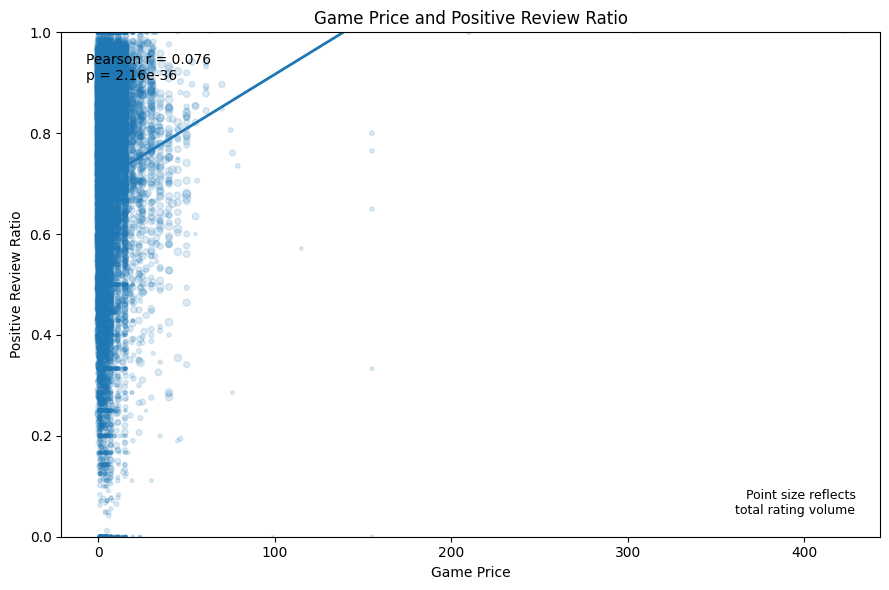

In [4]:
import matplotlib.pyplot as plt

plot_data = steam.sample(
    n=min(20_000, len(steam)),
    random_state=42,
)

x = plot_data["price"]
y = plot_data["positive_ratio"]

slope, intercept = np.polyfit(
    x,
    y,
    1,
)

x_line = np.linspace(
    x.min(),
    x.max(),
    200,
)

point_sizes = (
    np.log1p(
        plot_data["total_ratings"]
    )
    * 3
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    x,
    y,
    s=point_sizes,
    alpha=0.15,
)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
)

ax.set_title(
    "Game Price and Positive Review Ratio"
)

ax.set_xlabel(
    "Game Price"
)

ax.set_ylabel(
    "Positive Review Ratio"
)

ax.set_ylim(0, 1)

ax.text(
    0.03,
    0.96,
    (
        f"Pearson r = {corr:.3f}\n"
        f"p = {p_value:.3g}"
    ),
    transform=ax.transAxes,
    va="top",
)

ax.text(
    0.97,
    0.04,
    "Point size reflects\ntotal rating volume",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()

## Conclusion

The analysis finds a weak positive correlation between listed game price and positive review ratio (**r ≈ 0.076**).

This suggests that higher-priced games tend to receive slightly better user ratings on average, although the relationship is weak.
